# TS7 - Filtrado digital lineal de ECG 


In [1]:
import numpy as np, scipy.io as sio
from scipy import signal as sig
import matplotlib.pyplot as plt

fs = 1000
mat = sio.loadmat('ecg.mat')
ecg = mat['ecg_lead'].flatten()
N = len(ecg)

## a) Plantilla pasabanda
Ripple en banda de paso = 1db
Atenuacion en banda rechazo = 40db

Segun lo determinado en la TS6: el ancho de banda de una señal de ECG va desde 0.5Hz - 40Hz (aproximadamente)

In [14]:
ripple, aten = 1, 40                     # dB: ripple en banda de paso / atenuacion en rechazo
ws1, wp1, wp2, ws2 = 0.5, 1.0, 40, 50    # Hz: rechazo-paso-paso-rechazo

# Plantilla normalizada (0..1) y sus ganancias en veces (para graficar como "muro")
frecs = np.array([0, ws1, wp1, wp2, ws2, nyq]) / nyq
gains = 10**(np.array([-aten, -aten, -ripple, -ripple, -aten, -aten]) / 20)


#############
# Plantilla #
#############
 
nyq_frec   = fs/2
ripple     = 1  # dB
atenuacion = 20 # dB
 
ws1 = 0.1 # Hz
wp1 = 0.5 # Hz
wp2 = 40  # Hz
ws2 = 50  # Hz
 
# plantilla normalizada a Nyquist en dB
frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ]) / nyq_frec
gains = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])
 
# convertimos a veces para las funciones de diseño
gains = 10**(gains/20)

## b) De donde salen los valores
El ECG util esta aproximadamente en **0.5 - 40 Hz** (Segun lo determinado en la TS6, con cierto margen de consideracion). Para eliminar las componentes de menor frecuencua, se deja 0.4hz de transicion en baja frecuencia, y 10hz en alta (en alta dejamos mas margen, para no dejar tan restringido el filtro)

Pongo el corte bajo en `ws1=0.1 / wp1=0.5` 

y El corte alto `wp2=40 / ws2=50`

## c) Diseño: 2 IIR + 2 FIR
- **IIR** con `iirdesign`: Butterworth y Cauer.
- **FIR**: `firwin2` (muestreo en frecuencia) y `remez` (equiripple).

El borde de baja frecuencia es muy exigente (transición angosta 0.5→0.1 Hz): el IIR la cumple con
orden bajo, el FIR necesita **orden alto** para acercarse.

In [15]:
# ------ IIR ------
sos_butter = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple, aten, fs=fs, ftype='butter', output='sos')
sos_ellip  = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple, aten, fs=fs, ftype='ellip',  output='sos')

# ------ FIR ------
Nfir = 10001                                   # impar -> fase lineal tipo I, demora entera
h_firwin2 = sig.firwin2(Nfir, frecs, gains)   # muestrea la plantilla en frecuencia
h_remez   = sig.remez(Nfir, [0, ws1, wp1, wp2, ws2, nyq], [0, 1, 0],
                      weight=[10, 1, 5], fs=fs)  # equiripple, pesos: mas exigente en deriva

print('Orden IIR  butter:', sos_butter.shape[0]*2, ' ellip:', sos_ellip.shape[0]*2)
print('Taps FIR:', Nfir)

Orden IIR  butter: 46  ellip: 10
Taps FIR: 10001


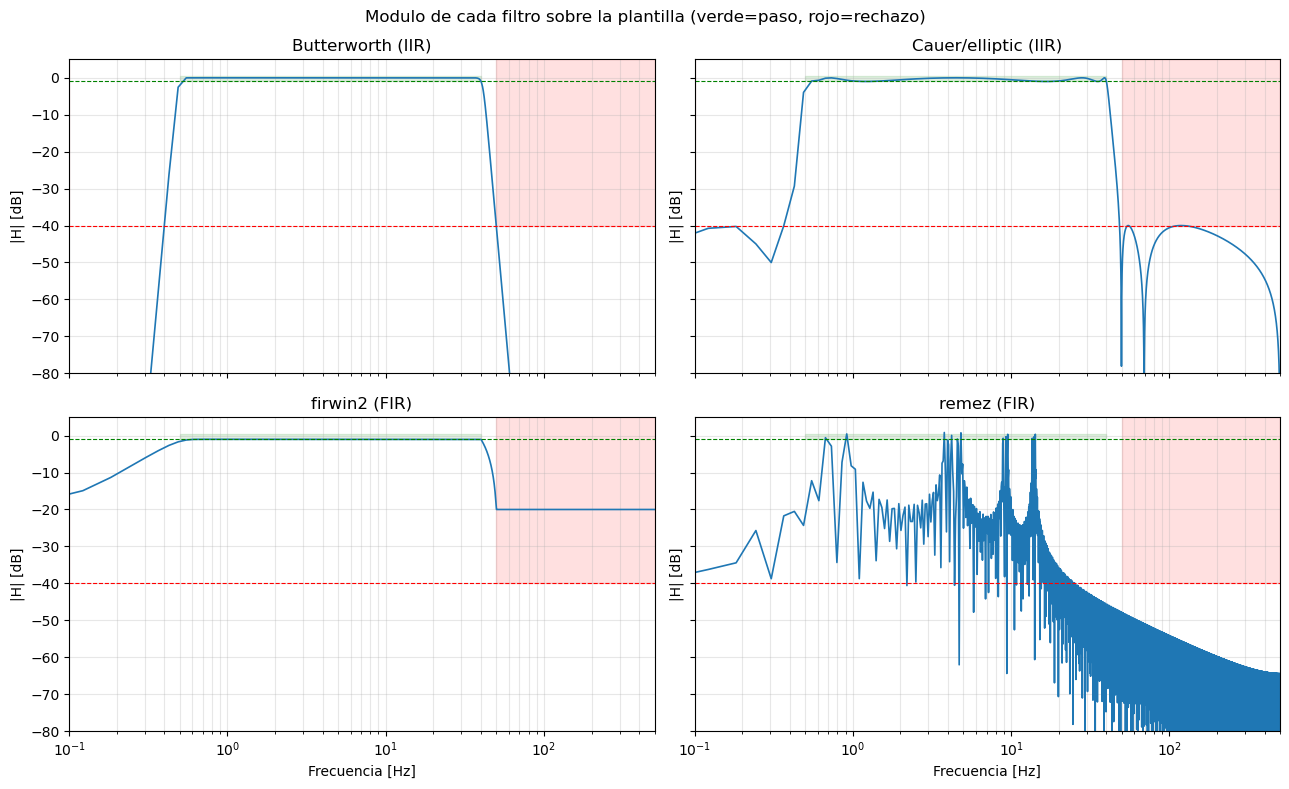

In [16]:
#%% c) Modulo (dB) de cada filtro sobre la plantilla
def H_db(filtro, fir=False):
    if fir: w, H = sig.freqz(filtro, worN=8192, fs=fs)
    else:   w, H = sig.sosfreqz(filtro, worN=8192, fs=fs)
    return w, 20*np.log10(np.abs(H) + 1e-12)

filtros = [('Butterworth (IIR)', sos_butter, False), ('Cauer/elliptic (IIR)', sos_ellip, False),
           ('firwin2 (FIR)', h_firwin2, True),       ('remez (FIR)', h_remez, True)]

fig, axs = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, (nombre, f, fir) in zip(axs.flat, filtros):
    w, mod = H_db(f, fir)
    ax.plot(w, mod, lw=1.2, label=nombre)
    # Plantilla: muro de tolerancia (rechazo en -aten, paso entre -ripple y 0)
    ax.fill_between([0, ws1], -aten, 5, color='r', alpha=.12)       # rechazo baja
    ax.fill_between([ws2, nyq], -aten, 5, color='r', alpha=.12)     # rechazo alta
    ax.fill_between([wp1, wp2], -ripple, .5, color='g', alpha=.12)  # paso
    ax.axhline(-aten, color='r', ls='--', lw=.8); ax.axhline(-ripple, color='g', ls='--', lw=.8)
    ax.set_title(nombre); ax.set_xscale('log'); ax.set_xlim(0.1, nyq); ax.set_ylim(-80, 5)
    ax.grid(True, which='both', alpha=.3); ax.set_ylabel('|H| [dB]')
for ax in axs[1]: ax.set_xlabel('Frecuencia [Hz]')
fig.suptitle('Modulo de cada filtro sobre la plantilla (verde=paso, rojo=rechazo)')
plt.tight_layout(); plt.show()

## d) Filtrado de la señal: región con ruido y región limpia
Filtro con el **Cauer** (IIR, `sosfiltfilt`, fase cero) y con el **firwin2** (FIR, `lfilter`,
compensando la demora `(Nfir-1)//2`). Comparo original vs filtrada en una zona ruidosa y una limpia.

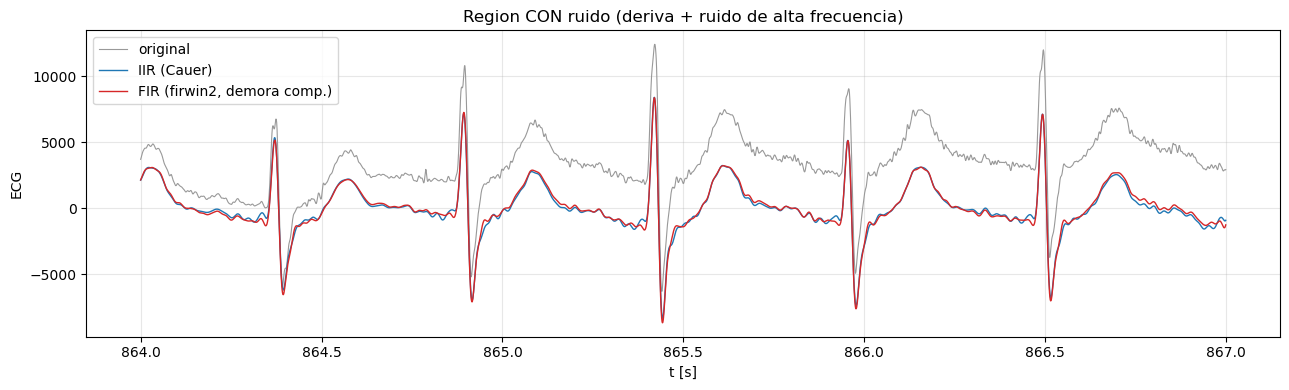

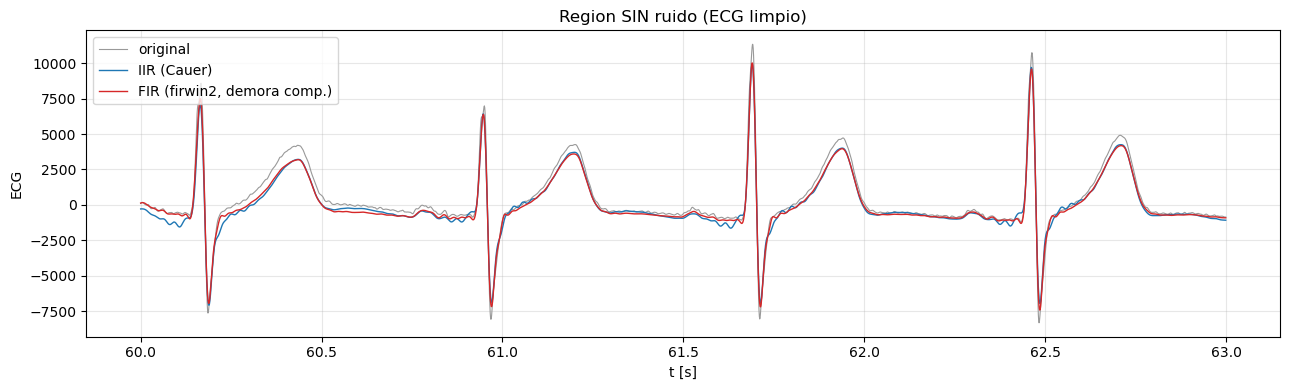

In [5]:
#%% d) Aplico un IIR y un FIR a toda la señal
d_fir = (Nfir - 1)//2                       # demora del FIR de fase lineal
ecg_iir = sig.sosfiltfilt(sos_ellip, ecg)   # fase cero -> sin demora
ecg_fir = sig.lfilter(h_firwin2, 1, ecg)    # causal -> hay que correrla d_fir muestras

def plot_region(ini, dur, titulo):
    t = np.arange(ini, ini+dur)/fs
    plt.figure(figsize=(13, 4))
    plt.plot(t, ecg[ini:ini+dur], color='.6', lw=.8, label='original')
    plt.plot(t, ecg_iir[ini:ini+dur], 'C0', lw=1, label='IIR (Cauer)')
    plt.plot(t, ecg_fir[ini+d_fir:ini+d_fir+dur], 'C3', lw=1, label='FIR (firwin2, demora comp.)')
    plt.title(titulo); plt.xlabel('t [s]'); plt.ylabel('ECG'); plt.grid(alpha=.3); plt.legend()
    plt.tight_layout(); plt.show()

plot_region(864000, 3000, 'Region CON ruido (deriva + ruido de alta frecuencia)')
plot_region( 60000, 3000, 'Region SIN ruido (ECG limpio)')

## Conclusiones
- **IIR (Cauer)** cumple la plantilla con **orden bajo** y es la opción práctica para el corte de baja
  frecuencia; usado con `sosfiltfilt` no introduce demora.
- **FIR** cumple fácil la banda alta, pero el corte bajo (transición angosta) le exige **orden muy alto**;
  `remez` (equiripple) sigue mejor la plantilla que `firwin2` (transición más suave).
- En la zona ruidosa el filtro **saca la deriva** (línea isoeléctrica a 0) y el **ruido de alta**; en la
  zona limpia **no deforma** el ECG (QRS y onda T se conservan).